<a href="https://colab.research.google.com/github/RabiaA-arif/AI/blob/main/nlp_practise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BPE (byte pair encoding)
bpe is the technique in nlp spiliting words into small words which is understandable know as subwords

in bpe most frequent used word put in one place

# how work bpe
step 1 :initialize

step 2 :calculate the frequency

step 3 :find most frequent pair

step 4 :merge the most frequent pair

step 5 :update the frequency of merge pair

step 6 : new word

step 7 :represents word


In [ ]:
from collections import defaultdict


In [ ]:
from collections import defaultdict

def learn_bpe(corpus, num_merges=3):
    # Step 1: Initialize word token counts. Each word is a sequence of characters.
    word_token_counts = defaultdict(int)
    for sentence in corpus.splitlines(): # Split by lines to handle multi-line corpus
        for word in sentence.strip().split(): # Strip whitespace and split into words
            # Represent each word as a tuple of characters with start/end markers
            token_sequence = tuple(['<'] + list(word) + ['>'])
            word_token_counts[token_sequence] += 1

    merges = [] # To store the learned merges (pairs)

    for _ in range(num_merges):
        # Step 2 & 3: Calculate frequencies of all adjacent pairs and find the most frequent
        pair_counts = defaultdict(int)
        for token_sequence, count in word_token_counts.items():
            for i in range(len(token_sequence) - 1):
                pair_counts[(token_sequence[i], token_sequence[i+1])] += count

        if not pair_counts: # If no more pairs can be formed, break
            break

        # Find the pair with the highest frequency
        most_frequent_pair = max(pair_counts, key=pair_counts.get)
        merges.append(most_frequent_pair)

        # Step 4 & 5: Merge the most frequent pair into a new token and update word_token_counts
        new_token = ''.join(most_frequent_pair) # Create the new merged token (e.g., ('l', 'o') -> 'lo')

        updated_word_token_counts = defaultdict(int)
        for token_sequence, count in word_token_counts.items():
            merged_sequence = []
            i = 0
            while i < len(token_sequence):
                if i + 1 < len(token_sequence) and (token_sequence[i], token_sequence[i+1]) == most_frequent_pair:
                    merged_sequence.append(new_token) # Add the new merged token
                    i += 2 # Skip the next token as it's been merged
                else:
                    merged_sequence.append(token_sequence[i])
                    i += 1
            updated_word_token_counts[tuple(merged_sequence)] += count
        word_token_counts = updated_word_token_counts # Update for the next iteration

    # Step 6 & 7: The final word_token_counts represents the words with new subwords.
    # We can also derive the final vocabulary of all unique tokens.
    final_vocabulary_tokens = set()
    for token_sequence in word_token_counts.keys():
        for token in token_sequence:
            final_vocabulary_tokens.add(token)

    return merges, sorted(list(final_vocabulary_tokens)), word_token_counts

In [ ]:
def apply_bpe(text, merges):
    chars = ['<'] + list(text) + ['>']
    for merge in reversed(merges):
        merged = ''.join(merge)
        new_chars = []
        i = 0
        while i < len(chars) - 1:
            if (chars[i], chars[i+1]) == merge:
                new_chars.append(merged)
                i += 2
            else:
                new_chars.append(chars[i])
                i += 1
        if i < len(chars):
            new_chars.append(chars[-1])
        chars = new_chars

    return chars

In [ ]:
def apply_bpe(text, merges):
    chars = ['<'] + list(text) + ['>']
    for merge in reversed(merges):
        merged = ''.join(merge)
        new_chars = []
        i = 0
        while i < len(chars) - 1:
            if (chars[i], chars[i+1]) == merge:
                new_chars.append(merged)
                i += 2
            else:
                new_chars.append(chars[i])
                i += 1
        if i < len(chars):
            new_chars.append(chars[-1])
        chars = new_chars

    return chars

In [ ]:
# Example usage
corpus = "ab bc bcd cde"
merges = learn_bpe(corpus, num_merges=3)
print("Learned Merges:", merges)
bpe_representation = apply_bpe("bcd", merges)
print("BPE Representation for 'bcd':", bpe_representation)

# BPE Tokenizer





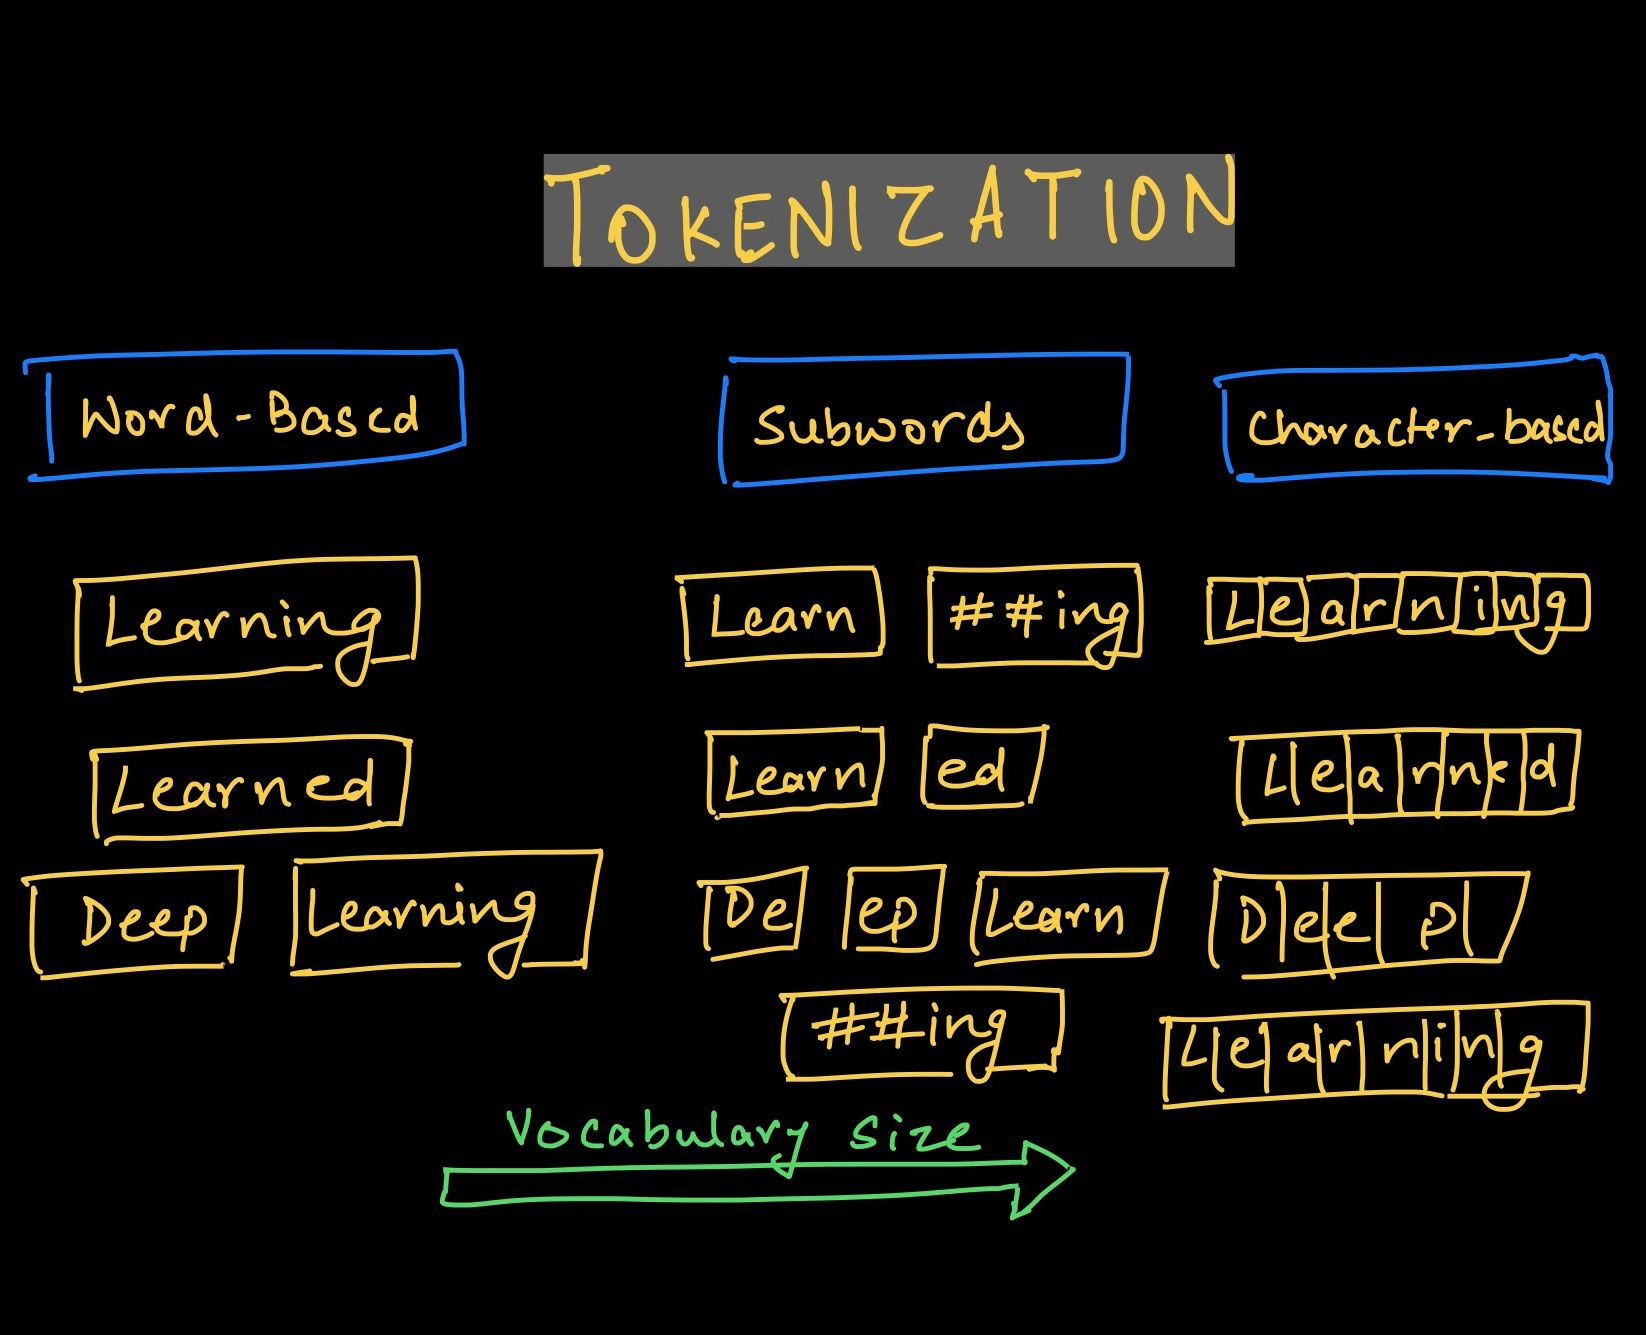

🔅
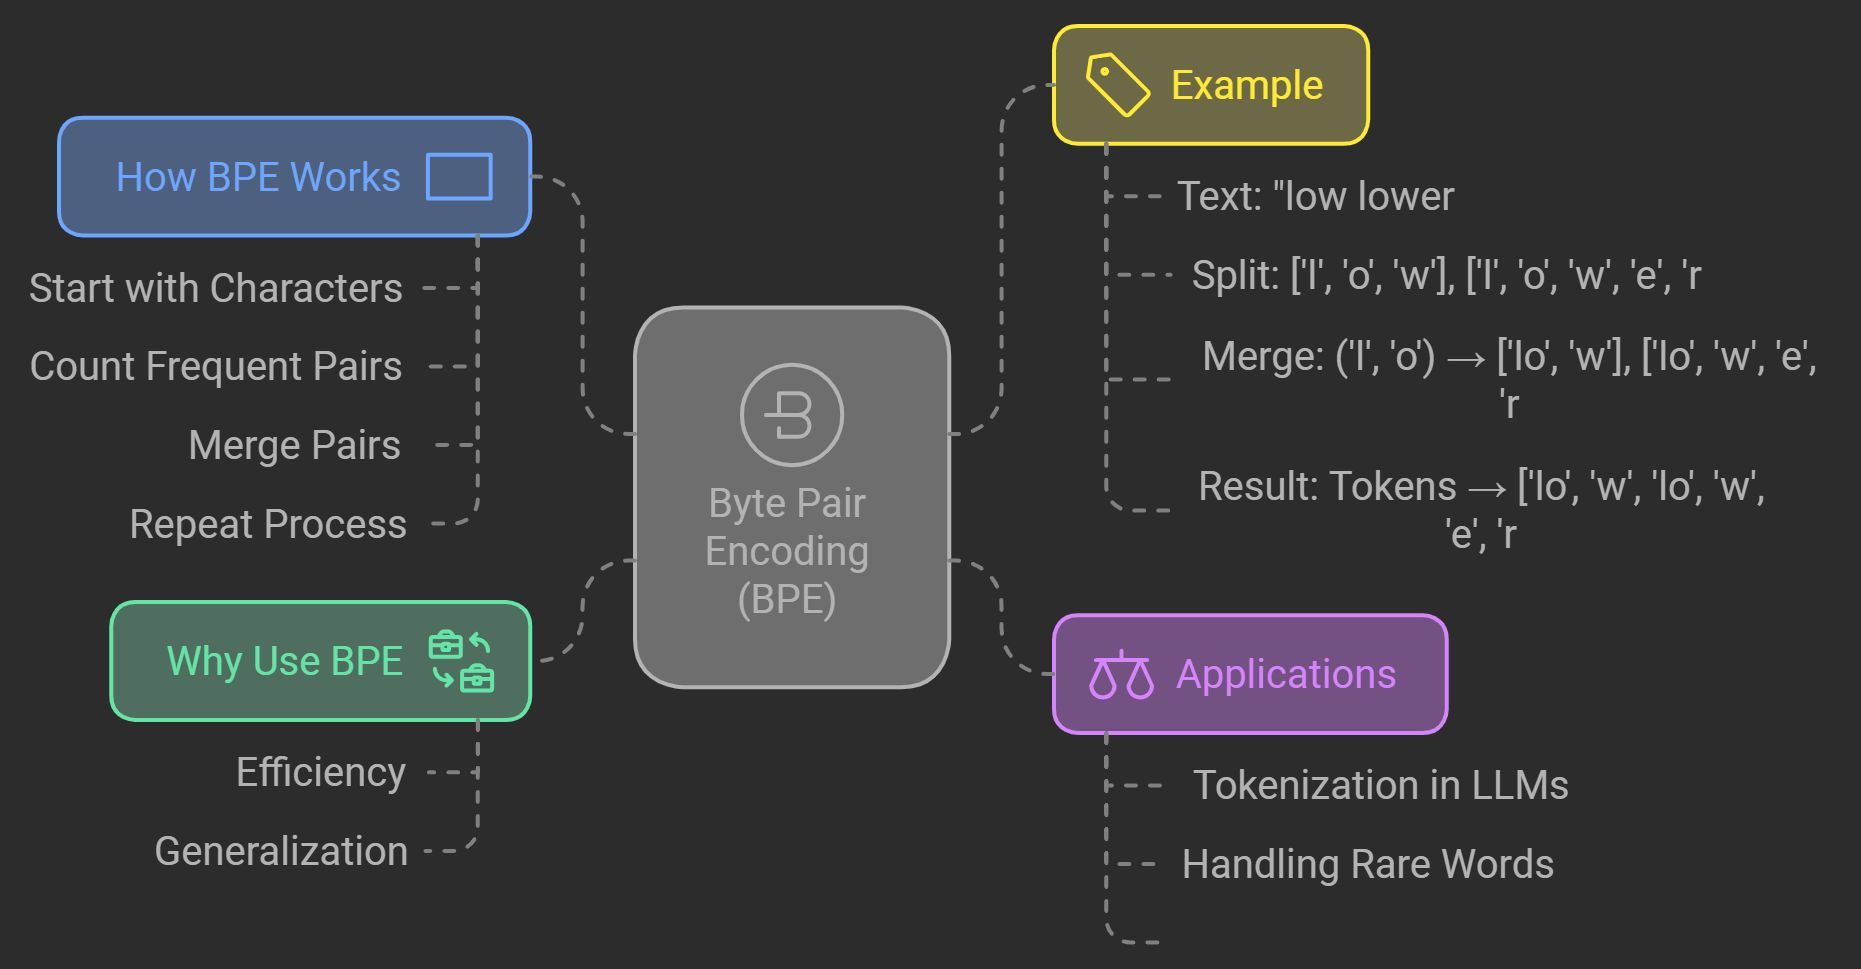

In [ ]:
import nltk
nltk.download('punkt_tab')


# ◀ Lemmatization in NLP

![lemmatization vs stemming](https://www.nomidl.com/wp-content/uploads/2023/02/image-23.png)

#lemmatize process
![](https://media.licdn.com/dms/image/v2/D4D12AQHN6JBdNSJCgg/article-cover_image-shrink_720_1280/article-cover_image-shrink_720_1280/0/1709744731810?e=2147483647&v=beta&t=jKPXbuQShvpxIZJVwTJqmgClqodK_AtPEIWxKWLYd5M)

[link text](https://medium.com/@kevinnjagi83/lemmatization-in-nlp-2a61012c5d66)

Lemimatization is more advanced technique in text as compared to stemming

in this technique consider word meaning and part of speech to reduce in it base form



In [ ]:
!pip install nltk

In [ ]:
import nltk
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
lemmatizer=WordNetLemmatizer()
print(lemmatizer.lemmatize("better"))
print(lemmatizer.lemmatize("painting",pos="a"))

In [ ]:
from nltk.corpus import wordnet
print(lemmatizer.lemmatize("running",pos=wordnet.VERB))
print(lemmatizer.lemmatize("best",pos=wordnet.ADJ))

In [ ]:
import nltk
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

lemmatizer=WordNetLemmatizer()

In [ ]:
def get_wordnet_pos(tag):
  if tag.startswith('J'):
    return wordnet.ADJ
  elif tag.startswith('V'):
    return wordnet.VERB
  elif tag.startswith("N"):
    return wordnet.NOUN
  elif tag.startswith("R"):
    return wordnet.ADV
  else:
    return None

In [ ]:
sentence="we are waiting the for the class,today is labor day htat why our library is close "
tokens=nltk.word_tokenize(sentence)
nltk.download('averaged_perceptron_tagger_eng')
pos_tags=nltk.pos_tag(tokens)

In [ ]:
lemmatized_tokens = []
for token, tag in pos_tags:
    wordnet_pos = get_wordnet_pos(tag)
    if wordnet_pos:
        lemmatized_tokens.append(lemmatizer.lemmatize(token, pos=wordnet_pos))
    else:
        lemmatized_tokens.append(lemmatizer.lemmatize(token)) # default to noun if no specific POS found

print("Original Tokens:", tokens)
print("POS Tags:", pos_tags)
print("Lemmatized Tokens:", lemmatized_tokens)

In [ ]:
lemmatized_sentence=[]

for tokens ,tag in pos_tags:
  wordnet_pos=get_wordnet_pos(tag) or wordnet.NOUN
  lemmatized_sentence.append(lemmatizer.lemmatize(tokens,pos=wordnet_pos))

In [ ]:
print("original sentence",sentence)
print("lemmatized sentence",lemmatized_sentence)